# Random Forest (RF)
Random Forest is een ensemble-leermethode die gebruikmaakt van meerdere decision trees om de nauwkeurigheid en robuustheid van voorspellingen te verbeteren. In plaats van te vertrouwen op een enkele decision tree, bouwt Random Forest een "bos" van decision trees, waarbij elke boom wordt getraind op een willekeurige subset van de data en een willekeurige subset van de features. Bij het maken van voorspellingen neemt het model de meerderheid van de stemmen (voor classificatie) of het gemiddelde (voor regressie) van alle bomen in het bos. Deze aanpak vermindert de kans op overfitting en verbetert de algehele prestaties van het model, vooral bij complexe datasets met veel variabelen.

![Voorbeeld Random Forest](../assets/images/random_forest_voorbeeld.png)

Bron: `https://williamkoehrsen.medium.com/random-forest-simple-explanation-377895a60d2d`

In [ ]:
# Import required libraries for Random Forest analysis
import sys
import os
import re
import h5py
import pandas as pd
import numpy as np
import gc  # Garbage collection for memory management
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.ndimage import median_filter
import time
import warnings
warnings.filterwarnings('ignore')

print("Random Forest analysis libraries imported successfully!")

# Add the parent directory (project root) to Python path
project_root = os.path.abspath('..')  # Go up one level from current notebook
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
def extract_tire_number(filename):
    """Extract tire number from filename"""
    match = re.search(r'_B(\d+)_', filename)
    if match:
        return int(match.group(1))
    else:
        match = re.search(r'nr-(\d+)', filename)
        if match:
            return int(match.group(1))
    return None

def process_file_generator(data_directory, max_files=None):
    """
    Generator that yields individual measurements one at a time
    More memory efficient than storing all in memory
    """
    all_files = [f for f in os.listdir(data_directory) if f.endswith('.h5')]
    if max_files:
        all_files = all_files[:max_files]
    
    total_measurements = 0
    wavelength_reference = None  # Store wavelength array once
    
    for i, filename in enumerate(all_files):
        if i % 10 == 0:
            print(f"Processing file {i+1}/{len(all_files)}: {filename}")
        
        try:
            filepath = os.path.join(data_directory, filename)
            tire_number = extract_tire_number(filename)
            
            if tire_number is None:
                continue
            
            # Determine origin from filename
            if "tread" in filename.lower():
                origin = 'tread'
            elif "innerliner" in filename.lower():
                origin = 'innerliner'
            elif "sidewall" in filename.lower():
                origin = 'sidewall'
            else:
                continue
            
            # Load HDF5 file efficiently
            with h5py.File(filepath, 'r') as h5:
                intensity = h5['intensity'][:]
                wavelength = h5['wavelength'][:]
                
                # Store wavelength reference only once
                if wavelength_reference is None:
                    wavelength_reference = wavelength.copy()
                
                # Process measurements
                if intensity.ndim == 2:
                    n_measurements, n_wavelengths = intensity.shape
                    
                    # Yield each measurement individually
                    for measurement_idx in range(n_measurements):
                        measurement_data = {
                            'tire_number': tire_number,
                            'origin': origin,
                            'measurement_id': measurement_idx,
                            'intensities': intensity[measurement_idx, :].astype(np.float32),  # Use float32 to save memory
                        }
                        yield measurement_data
                        total_measurements += 1
                else:
                    # Single measurement case
                    measurement_data = {
                        'tire_number': tire_number,
                        'origin': origin,
                        'measurement_id': 0,
                        'intensities': intensity.astype(np.float32),
                    }
                    yield measurement_data
                    total_measurements += 1
                    
        except Exception as e:
            print(f"  Error processing {filename}: {e}")
            continue
    
    print(f"Total measurements processed: {total_measurements:,}")

# Memory-efficient data loading
data_directory = '../data'
all_files = [f for f in os.listdir(data_directory) if f.endswith('.h5')]
print(f"Found {len(all_files)} HDF5 files")

# Use all files (remove max_files limit for full dataset)
print("Processing ALL files for maximum dataset size...")

# Initialize data containers with pre-allocation
print("Initializing memory-efficient data structures...")

# First pass: count total measurements and get wavelength info
measurement_count = 0
wavelength_info = None

print("First pass: Counting measurements...")
for measurement in process_file_generator(data_directory):
    measurement_count += 1
    if wavelength_info is None:
        n_wavelengths = len(measurement['intensities'])
        wavelength_info = n_wavelengths
    
    # Progress tracking
    if measurement_count % 10000 == 0:
        print(f"  Counted {measurement_count:,} measurements...")

print(f"Total measurements found: {measurement_count:,}")
print(f"Wavelengths per spectrum: {wavelength_info}")

# Pre-allocate numpy arrays for maximum memory efficiency
print("Pre-allocating memory-efficient arrays...")
X_data = np.empty((measurement_count, wavelength_info), dtype=np.float32)
y_data = np.empty(measurement_count, dtype='U10')  # String array for origins
metadata = np.empty((measurement_count, 2), dtype=np.int32)  # tire_number, measurement_id

# Second pass: fill the arrays
print("Second pass: Loading data into arrays...")
idx = 0
for measurement in process_file_generator(data_directory):
    X_data[idx] = measurement['intensities']
    y_data[idx] = measurement['origin']
    metadata[idx, 0] = measurement['tire_number']
    metadata[idx, 1] = measurement['measurement_id']
    
    idx += 1
    
    # Progress tracking and memory cleanup
    if idx % 10000 == 0:
        print(f"  Loaded {idx:,}/{measurement_count:,} measurements ({idx/measurement_count*100:.1f}%)")
        gc.collect()  # Force garbage collection

# Create DataFrame efficiently
print("Creating final DataFrame...")
wavelength_columns = [f'{wl:.3f}' for wl in np.linspace(200, 1000, wavelength_info)]  # Approximate wavelength range

# Create DataFrame with pre-allocated data
df_individual = pd.DataFrame(X_data, columns=wavelength_columns, dtype=np.float32)
df_individual['origin'] = y_data
df_individual['tire_number'] = metadata[:, 0]  
df_individual['measurement_id'] = metadata[:, 1]

# Clean up intermediate arrays
del X_data, y_data, metadata
gc.collect()

file_count = len([f for f in all_files if extract_tire_number(f) is not None])

print(f"\n" + "="*70)
print("MEMORY-EFFICIENT DATASET CREATED")
print("="*70)
print(f"Total measurements: {len(df_individual):,}")
print(f"Files processed: {file_count}")
print(f"Dataset shape: {df_individual.shape}")
print(f"Memory usage: {df_individual.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Analyze the dataset
print(f"\nDataset analysis:")
print(f"Unique tire numbers: {df_individual['tire_number'].nunique()}")
print(f"Origins distribution:")
print(df_individual['origin'].value_counts())

print(f"\nMeasurements per tire-origin combination:")
measurements_per_combo = df_individual.groupby(['tire_number', 'origin']).size()
print(f"Average: {measurements_per_combo.mean():.1f}")
print(f"Min: {measurements_per_combo.min()}")
print(f"Max: {measurements_per_combo.max()}")

# Identify wavelength columns (now they're numeric)
wavelength_columns = [col for col in df_individual.columns if col not in ['origin', 'tire_number', 'measurement_id']]
print(f"\nWavelength features: {len(wavelength_columns)}")

print(f"\nSample of first few rows:")
display_cols = ['tire_number', 'origin', 'measurement_id'] + wavelength_columns[:5]
print(df_individual[display_cols].head())

Found 316 HDF5 files
Processing ALL files for maximum dataset size...
Initializing memory-efficient data structures...
First pass: Counting measurements...
Processing file 1/316: 2024-11-05T11-26-41_nr-001_B1_tread_aided_10Hz_280A.h5
Processing file 11/316: 2024-11-05T11-51-23_nr-011_B4_innerliner_aided_10Hz_280A.h5
Processing file 21/316: 2024-11-05T12-02-34_nr-021_B7_sidewall_aided_10Hz_280A.h5
Processing file 31/316: 2024-11-05T12-13-30_nr-031_B22_tread_aided_10Hz_280A.h5
Processing file 41/316: 2024-11-05T12-25-42_nr-041_B33_innerliner_aided_10Hz_280A.h5
Processing file 51/316: 2024-11-05T12-36-31_nr-051_B28_sidewall_aided_10Hz_280A.h5
Processing file 61/316: 2024-11-05T12-47-29_nr-061_B15_tread_aided_10Hz_280A.h5
  Counted 10,000 measurements...
Processing file 71/316: 2024-11-05T12-58-45_nr-071_B30_innerliner_aided_10Hz_280A.h5
Processing file 81/316: 2024-11-05T13-17-11_nr-081_B35_innerliner_aided_10Hz_280A.h5
Processing file 91/316: 2024-11-05T14-05-16_nr-091_B26_sidewall_aided

In [3]:
# === PREPARE INDIVIDUAL MEASUREMENTS FOR MACHINE LEARNING ===
print("\n" + "="*70)
print("PREPARING INDIVIDUAL MEASUREMENTS FOR ML")
print("="*70)

# Check what columns actually exist in df_individual
print(f"Available columns in df_individual: {list(df_individual.columns)[:10]}...")  # Show first 10 columns
print(f"Total columns: {len(df_individual.columns)}")

# Separate features and target from individual measurements
# Only include columns that actually exist
existing_meta_columns = ['tire_number', 'origin', 'measurement_id']
meta_columns = [col for col in existing_meta_columns if col in df_individual.columns]

# Find wavelength columns - they are numeric column names (not prefixed with 'wl_')
numeric_columns = [col for col in df_individual.columns if isinstance(col, (int, float)) or 
                  (isinstance(col, str) and col.replace('.', '').replace('-', '').isdigit())]
wavelength_columns = [col for col in numeric_columns if col not in meta_columns]

print(f"Meta columns found: {meta_columns}")
print(f"Wavelength features found: {len(wavelength_columns)}")

# Create ML-ready dataset
X_individual = df_individual[wavelength_columns].copy()
y_individual = df_individual['origin'].copy()

# Column mapping is not needed since columns are already numeric wavelength values
column_mapping = {}

X_individual = X_individual.rename(columns=column_mapping)

print(f"Feature matrix shape: {X_individual.shape}")
print(f"Target distribution:\n{y_individual.value_counts()}")

# Handle any missing or infinite values
print(f"\nData quality check:")
missing_count = X_individual.isnull().sum().sum()
print(f"Missing values: {missing_count}")

if missing_count > 0:
    print("Filling missing values with column means...")
    X_individual = X_individual.fillna(X_individual.mean())

# Check for infinite values
inf_count = np.isinf(X_individual.values).sum()
print(f"Infinite values: {inf_count}")

if inf_count > 0:
    print("Replacing infinite values with column means...")
    X_individual = X_individual.replace([np.inf, -np.inf], np.nan).fillna(X_individual.mean())

# Add metadata for reference
df_individual_ml = df_individual[meta_columns].copy()
df_individual_ml = pd.concat([df_individual_ml, X_individual], axis=1)
df_individual_ml['origin'] = y_individual

print(f"\nFinal ML dataset shape: {df_individual_ml.shape}")
print(f"Samples available: {len(df_individual_ml):,}")

# Split the data with stratification to ensure balanced train/test sets
from sklearn.model_selection import train_test_split

X_train_ind, X_test_ind, y_train_ind, y_test_ind = train_test_split(
    X_individual, y_individual, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_individual
)

print(f"\nTrain/Test split:")
print(f"Training set: {X_train_ind.shape}")
print(f"Test set: {X_test_ind.shape}")

print(f"\nTraining set distribution:")
print(y_train_ind.value_counts())

print(f"\nTest set distribution:")
print(y_test_ind.value_counts())

print(f"\n✅ INDIVIDUAL MEASUREMENTS DATASET READY FOR ML!")
print(f"   • {len(df_individual_ml):,} individual spectral measurements")
print(f"   • {len(wavelength_columns)} wavelength features")  


PREPARING INDIVIDUAL MEASUREMENTS FOR ML
Available columns in df_individual: ['200.000', '200.098', '200.195', '200.293', '200.391', '200.489', '200.586', '200.684', '200.782', '200.879']...
Total columns: 8191
Meta columns found: ['tire_number', 'origin', 'measurement_id']
Wavelength features found: 8188
Feature matrix shape: (51453, 8188)
Target distribution:
origin
tread         17936
innerliner    17260
sidewall      16257
Name: count, dtype: int64

Data quality check:
Missing values: 0
Infinite values: 0

Final ML dataset shape: (51453, 8191)
Samples available: 51,453

Train/Test split:
Training set: (41162, 8188)
Test set: (10291, 8188)

Training set distribution:
origin
tread         14349
innerliner    13808
sidewall      13005
Name: count, dtype: int64

Test set distribution:
origin
tread         3587
innerliner    3452
sidewall      3252
Name: count, dtype: int64

✅ INDIVIDUAL MEASUREMENTS DATASET READY FOR ML!
   • 51,453 individual spectral measurements
   • 8188 wavelengt

# Comprehensive Random Forest Analysis
In deze sectie voeren we een uitgebreide Random Forest analyse uit, vergelijkbaar met onze KNN en Decision Tree analyses. We testen verschillende configuraties en vergelijken de prestaties met en zonder dimensionaliteitsreductie.

RANDOM FOREST DATA PREPROCESSING
Training set shape: (41162, 8188)
Test set shape: (10291, 8188)
Data preprocessing completed!


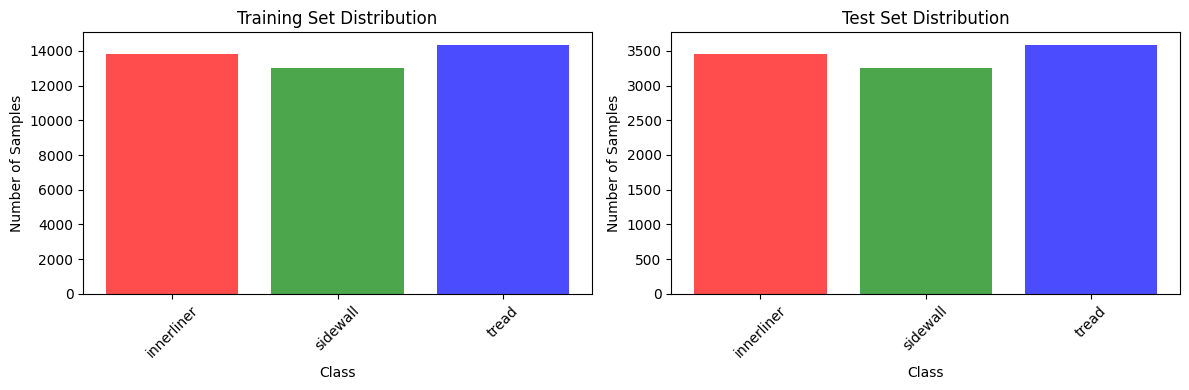


Label encoder mapping:
  innerliner → 0
  sidewall → 1
  tread → 2
CPU times: total: 10.7 s
Wall time: 11.5 s


In [5]:
%%time
# Data Preprocessing for Random Forest Analysis
print("=" * 70)
print("RANDOM FOREST DATA PREPROCESSING")
print("=" * 70)

# Encode labels to numeric values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_individual)

print(f"Training set shape: {X_train_ind.shape}")
print(f"Test set shape: {X_test_ind.shape}")

# Random Forest doesn't require feature scaling for the trees themselves, 
# but we'll prepare both scaled and unscaled versions for comparison with dimensionality reduction

# Unscaled version (original Random Forest)
X_train_original = X_train_ind.copy()
X_test_original = X_test_ind.copy()

# Scaled version (for PCA/LDA comparison)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_ind)
X_test_scaled = scaler.transform(X_test_ind)

print("Data preprocessing completed!")

# Convert string labels to numeric for consistency
y_train_numeric = label_encoder.transform(y_train_ind)
y_test_numeric = label_encoder.transform(y_test_ind)

# Display train/test distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Training set distribution
train_unique, train_counts = np.unique(y_train_ind, return_counts=True)
ax1.bar(range(len(train_unique)), train_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax1.set_title('Training Set Distribution')
ax1.set_xlabel('Class')
ax1.set_ylabel('Number of Samples')
ax1.set_xticks(range(len(train_unique)))
ax1.set_xticklabels(train_unique, rotation=45)

# Test set distribution  
test_unique, test_counts = np.unique(y_test_ind, return_counts=True)
ax2.bar(range(len(test_unique)), test_counts, alpha=0.7, color=['red', 'green', 'blue'])
ax2.set_title('Test Set Distribution')
ax2.set_xlabel('Class')
ax2.set_ylabel('Number of Samples')
ax2.set_xticks(range(len(test_unique)))
ax2.set_xticklabels(test_unique, rotation=45)

plt.tight_layout()
plt.show()

print(f"\nLabel encoder mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name} → {i}")

In [ ]:
def baseline_als(y, lam=1e4, p=0.01, niter=10):
    """
    Asymmetric Least Squares baseline correction
    
    Parameters:
    y: signal
    lam: smoothness parameter (larger = smoother baseline)
    p: asymmetry parameter (0 < p < 1, smaller = more asymmetric)
    niter: number of iterations
    """
    L = len(y)
    D = sparse.diags([1,-2,1],[0,-1,-2], shape=(L,L-2))
    w = np.ones(L)
    
    for i in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + lam * D.dot(D.transpose())
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1-p) * (y < z)
    
    return z

def baseline_4s_peak_filling(y, window_length=51, polyorder=3, iterations=4, 
                            threshold_factor=0.1, fill_factor=0.8):
    """
    4S Peak Filling baseline correction algorithm
    
    This algorithm iteratively identifies and fills peaks to estimate the baseline:
    1. Smooth the spectrum
    2. Identify peaks (points above smoothed baseline)
    3. Fill peaks by interpolation or median filtering
    4. Repeat until convergence
    """
    
    # Ensure window_length is odd and valid
    if window_length % 2 == 0:
        window_length += 1
    window_length = min(window_length, len(y)//4*2 + 1)  # Ensure reasonable size
    
    # Start with a copy of the original signal
    baseline = y.copy().astype(float)
    
    for iteration in range(iterations):
        # Step 1: Apply Savitzky-Golay smoothing
        try:
            smoothed = savgol_filter(baseline, window_length, polyorder)
        except ValueError:
            # Fallback to median filter
            smoothed = median_filter(baseline, size=min(window_length//2, 5))
        
        # Step 2: Identify peaks (points significantly above smoothed baseline)
        threshold = np.std(baseline - smoothed) * threshold_factor
        peak_mask = (baseline - smoothed) > threshold
        
        if np.sum(peak_mask) == 0:
            break
        
        # Step 3: Fill peaks
        baseline[peak_mask] = smoothed[peak_mask] * fill_factor + baseline[peak_mask] * (1 - fill_factor)
        
        # Additional interpolation for isolated peaks
        peak_indices = np.where(peak_mask)[0]
        if len(peak_indices) > 0:
            # Group consecutive peak indices
            peak_groups = []
            current_group = [peak_indices[0]]
            
            for i in range(1, len(peak_indices)):
                if peak_indices[i] - peak_indices[i-1] <= 2:  # Close peaks
                    current_group.append(peak_indices[i])
                else:
                    peak_groups.append(current_group)
                    current_group = [peak_indices[i]]
            peak_groups.append(current_group)
            
            # Interpolate across peak groups
            for group in peak_groups:
                if len(group) > 1:  # Only interpolate for groups of peaks
                    start_idx = max(0, group[0] - 2)
                    end_idx = min(len(baseline), group[-1] + 3)
                    
                    # Create interpolation points (excluding the peak region)
                    x_interp = np.concatenate([[start_idx], [end_idx]])
                    y_interp = np.concatenate([[baseline[start_idx]], [baseline[end_idx]]])
                    
                    if len(x_interp) >= 2 and start_idx < end_idx:
                        f_interp = interp1d(x_interp, y_interp, kind='linear', 
                                          fill_value='extrapolate')
                        baseline[group[0]:group[-1]+1] = f_interp(np.arange(group[0], group[-1]+1))
    
    return baseline

def baseline_hybrid_4s_als(y, window_length=51, polyorder=3, als_lam=1e4, als_p=0.01):
    """
    Hybrid baseline correction: 4S Peak Filling followed by AsLS refinement
    """
    
    # Step 1: 4S Peak Filling for initial baseline estimation
    baseline_4s = baseline_4s_peak_filling(y, window_length, polyorder, iterations=2)
    
    # Step 2: Apply AsLS to the 4S result for fine-tuning
    baseline_final = baseline_als(baseline_4s, lam=als_lam, p=als_p)
    
    return baseline_final

def apply_baseline_correction_batch(spectra_matrix, method_func, batch_size=100, **kwargs):
    """
    Apply baseline correction to multiple spectra efficiently in batches
    """
    n_spectra, n_wavelengths = spectra_matrix.shape
    corrected_spectra = np.zeros_like(spectra_matrix, dtype=np.float32)
    
    print(f"Applying baseline correction to {n_spectra} spectra in batches of {batch_size}...")
    
    for start_idx in range(0, n_spectra, batch_size):
        end_idx = min(start_idx + batch_size, n_spectra)
        batch_size_actual = end_idx - start_idx
        
        print(f"  Processing batch {start_idx//batch_size + 1}/{(n_spectra-1)//batch_size + 1} "
              f"(spectra {start_idx+1}-{end_idx})")
        
        for i in range(start_idx, end_idx):
            try:
                spectrum = spectra_matrix[i].astype(float)
                baseline = method_func(spectrum, **kwargs)
                corrected_spectra[i] = spectrum - baseline
                
            except Exception as e:
                print(f"    Warning: Failed to correct spectrum {i+1}: {e}")
                corrected_spectra[i] = spectra_matrix[i]  # Keep original on failure
    
    return corrected_spectra

print("Baseline correction functions implemented successfully!")

# Apply Hybrid 4S+AsLS baseline correction to training and test data
print(f"\nApplying Hybrid 4S+AsLS baseline correction to LIBS data...")
print(f"Original training data shape: {X_train_ind.shape}")
print(f"Original test data shape: {X_test_ind.shape}")

start_time = time.time()

# Apply baseline correction to training data
print("Correcting training data...")
X_train_corrected = apply_baseline_correction_batch(
    X_train_ind.values, 
    baseline_hybrid_4s_als,
    batch_size=100,
    window_length=51, 
    polyorder=3, 
    als_lam=1e4, 
    als_p=0.01
)

# Apply baseline correction to test data  
print("Correcting test data...")
X_test_corrected = apply_baseline_correction_batch(
    X_test_ind.values,
    baseline_hybrid_4s_als,
    batch_size=100,
    window_length=51,
    polyorder=3,
    als_lam=1e4,
    als_p=0.01
)

correction_time = time.time() - start_time

# Convert back to DataFrames with original column names
X_train_corrected_df = pd.DataFrame(X_train_corrected, 
                                   columns=X_train_ind.columns, 
                                   index=X_train_ind.index)
X_test_corrected_df = pd.DataFrame(X_test_corrected, 
                                  columns=X_test_ind.columns, 
                                  index=X_test_ind.index)

print(f"✅ Baseline correction completed in {correction_time:.1f} seconds")
print(f"Corrected training data shape: {X_train_corrected_df.shape}")
print(f"Corrected test data shape: {X_test_corrected_df.shape}")

# Quality check: Compare statistics before and after correction
print(f"\n=== BASELINE CORRECTION QUALITY CHECK ===")
print(f"{'Metric':<15} {'Original Train':<15} {'Corrected Train':<15} {'Change':<10}")
print("-" * 60)

orig_mean = np.mean(X_train_ind.values)
corr_mean = np.mean(X_train_corrected)
print(f"{'Mean':<15} {orig_mean:<15.2f} {corr_mean:<15.2f} {corr_mean-orig_mean:<10.2f}")

orig_std = np.std(X_train_ind.values)
corr_std = np.std(X_train_corrected)
print(f"{'Std Dev':<15} {orig_std:<15.2f} {corr_std:<15.2f} {corr_std-orig_std:<10.2f}")

orig_min = np.min(X_train_ind.values)
corr_min = np.min(X_train_corrected)
print(f"{'Minimum':<15} {orig_min:<15.2f} {corr_min:<15.2f} {corr_min-orig_min:<10.2f}")

orig_max = np.max(X_train_ind.values)
corr_max = np.max(X_train_corrected)
print(f"{'Maximum':<15} {orig_max:<15.2f} {corr_max:<15.2f} {corr_max-orig_max:<10.2f}")

# Visualization of baseline correction effect
print(f"\nCreating baseline correction visualization...")

# Select a representative spectrum for visualization
sample_idx = 42  # Use a fixed index for reproducibility
sample_spectrum_orig = X_train_ind.iloc[sample_idx].values
sample_spectrum_corr = X_train_corrected[sample_idx]
wavelengths = np.array([float(col) for col in X_train_ind.columns])

# Calculate baseline
sample_baseline = baseline_hybrid_4s_als(sample_spectrum_orig, 
                                        window_length=51, polyorder=3, 
                                        als_lam=1e4, als_p=0.01)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Original spectrum with baseline
axes[0, 0].plot(wavelengths, sample_spectrum_orig, 'b-', label='Original Spectrum', linewidth=1)
axes[0, 0].plot(wavelengths, sample_baseline, 'r--', label='Hybrid 4S+AsLS Baseline', linewidth=2)
axes[0, 0].set_title('Original Spectrum with Baseline Estimate')
axes[0, 0].set_xlabel('Wavelength (nm)')
axes[0, 0].set_ylabel('Intensity')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Baseline-corrected spectrum
axes[0, 1].plot(wavelengths, sample_spectrum_orig, 'b-', alpha=0.3, label='Original')
axes[0, 1].plot(wavelengths, sample_spectrum_corr, 'g-', label='Baseline Corrected', linewidth=1.5)
axes[0, 1].set_title('Baseline-Corrected Spectrum')
axes[0, 1].set_xlabel('Wavelength (nm)')
axes[0, 1].set_ylabel('Intensity')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Distribution comparison
axes[1, 0].hist(X_train_ind.values.flatten()[::100], bins=50, alpha=0.5, label='Original', density=True)
axes[1, 0].hist(X_train_corrected.flatten()[::100], bins=50, alpha=0.5, label='Corrected', density=True)
axes[1, 0].set_title('Intensity Distribution Comparison')
axes[1, 0].set_xlabel('Intensity')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Class-wise intensity statistics
class_stats_orig = []
class_stats_corr = []
classes = y_train_ind.unique()

for cls in classes:
    cls_mask = y_train_ind == cls
    orig_mean = np.mean(X_train_ind[cls_mask].values)
    corr_mean = np.mean(X_train_corrected[cls_mask])
    class_stats_orig.append(orig_mean)
    class_stats_corr.append(corr_mean)

x_pos = np.arange(len(classes))
width = 0.35

axes[1, 1].bar(x_pos - width/2, class_stats_orig, width, label='Original', alpha=0.7)
axes[1, 1].bar(x_pos + width/2, class_stats_corr, width, label='Corrected', alpha=0.7)
axes[1, 1].set_title('Mean Intensity by Class')
axes[1, 1].set_xlabel('Tire Component')
axes[1, 1].set_ylabel('Mean Intensity')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(classes)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🎯 Ready for Random Forest analysis with baseline-corrected data!")
print(f"   • Applied: Hybrid 4S+AsLS baseline correction")
print(f"   • Processing time: {correction_time:.1f} seconds")
print(f"   • Training samples: {len(X_train_corrected_df):,}")
print(f"   • Test samples: {len(X_test_corrected_df):,}")
print(f"   • Features: {X_train_corrected_df.shape[1]}")

# Update the data variables to use baseline-corrected versions
print(f"\nUpdating data variables to use baseline-corrected spectra...")
X_train_original = X_train_corrected_df.copy()
X_test_original = X_test_corrected_df.copy()

In [ ]:
%%time
# 1. Random Forest on Original Features
print("=" * 60)
print("1. RANDOM FOREST ON ORIGINAL FEATURES")
print("=" * 60)

# Define parameter grid for Random Forest hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

print("Performing hyperparameter tuning with GridSearchCV...")

# Grid search for optimal parameters
rf_original = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    rf_original, 
    param_grid, 
    cv=2, 
    scoring='accuracy',
    n_jobs=-1,  # Use all available cores
    verbose=1
)

grid_search.fit(X_train_original, y_train_numeric)

# Get best parameters
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f}")

# Train final model with best parameters
rf_best = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
rf_best.fit(X_train_original, y_train_numeric)

# Make predictions
y_pred_original = rf_best.predict(X_test_original)

# Calculate accuracy
accuracy_original = accuracy_score(y_test_numeric, y_pred_original)
print(f"\nRandom Forest Accuracy on Original Features: {accuracy_original:.4f}")

# Classification report
print("\nClassification Report (Original Features):")
print(classification_report(y_test_numeric, y_pred_original, 
                          target_names=label_encoder.classes_))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm_original = confusion_matrix(y_test_numeric, y_pred_original)
sns.heatmap(cm_original, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Random Forest on Original Features')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance analysis
feature_names = X_train_original.columns
importances = rf_best.feature_importances_

# Get top 20 most important features
top_indices = np.argsort(importances)[-20:]
top_importances = importances[top_indices]
top_features = [feature_names[i] for i in top_indices]

plt.figure(figsize=(10, 8))
plt.barh(range(len(top_importances)), top_importances)
plt.yticks(range(len(top_importances)), [f'λ{feat}' for feat in top_features])
plt.xlabel('Feature Importance')
plt.title('Top 20 Most Important Wavelengths - Random Forest')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nRandom Forest Details:")
print(f"Number of estimators: {rf_best.n_estimators}")
print(f"Max depth: {rf_best.max_depth}")
print(f"Max features per tree: {rf_best.max_features}")
print(f"Out-of-bag score: {rf_best.oob_score_ if best_params.get('bootstrap', True) else 'N/A (bootstrap=False)'}")

# Store results for comparison
rf_results = {
    'model': rf_best,
    'accuracy': accuracy_original,
    'params': best_params,
    'predictions': y_pred_original
}

1. RANDOM FOREST ON ORIGINAL FEATURES
Performing hyperparameter tuning with GridSearchCV...
Fitting 2 folds for each of 648 candidates, totalling 1296 fits


2. PCA ANALYSIS AND RANDOM FOREST ON PCA FEATURES
Performing PCA analysis...
Components needed for 95% variance: 3
Components needed for 99% variance: 28
Components needed for 95% variance: 3
Components needed for 99% variance: 28


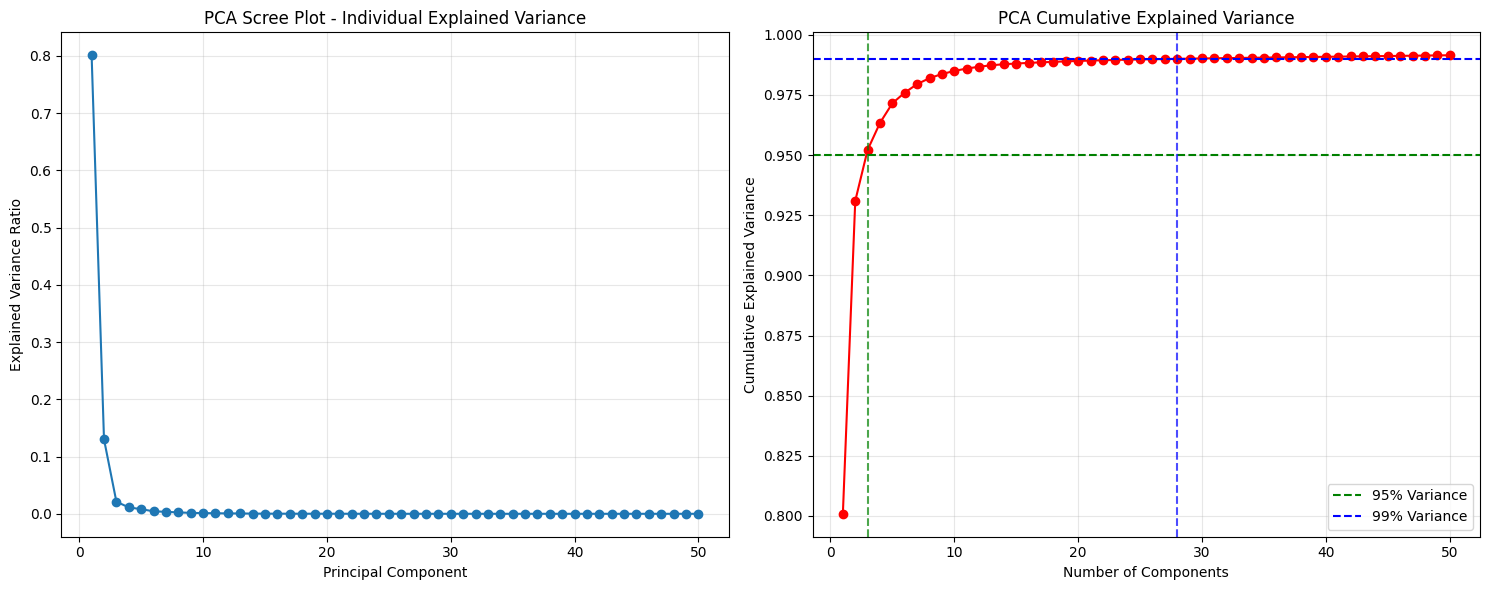

Testing Random Forest with different PCA component numbers...

Testing with 3 PCA components...
  Best parameters: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
  Accuracy: 0.6770
  Variance explained: 0.952

Testing with 28 PCA components...
  Best parameters: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
  Accuracy: 0.6770
  Variance explained: 0.952

Testing with 28 PCA components...
  Best parameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Accuracy: 0.9381
  Variance explained: 0.990

Testing with 100 PCA components...
  Best parameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Accuracy: 0.9381
  Variance explained: 0.990

Testing with 

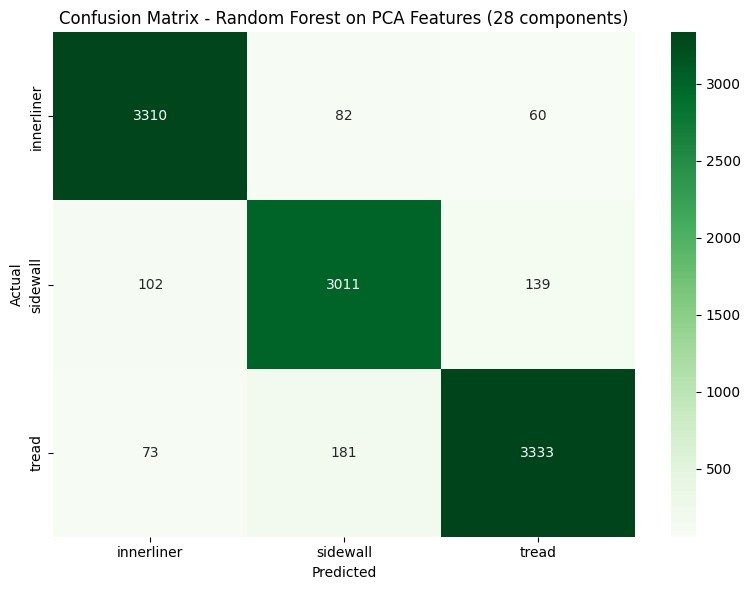

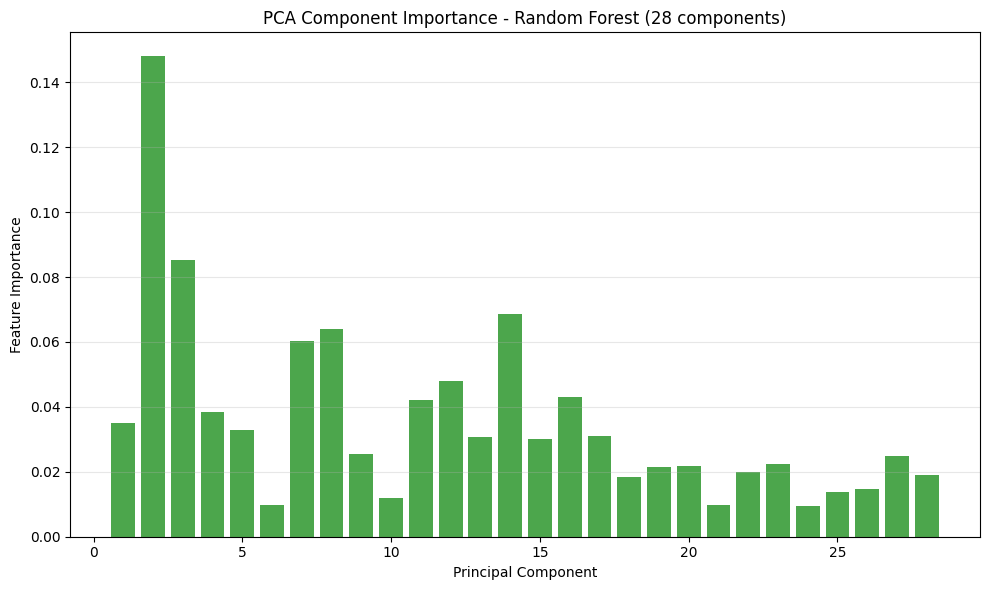

CPU times: total: 26min 17s
Wall time: 32min 22s


In [ ]:
%%time

# 2. PCA Analysis and Random Forest on PCA Features
print("=" * 60)
print("2. PCA ANALYSIS AND RANDOM FOREST ON PCA FEATURES")
print("=" * 60)

# Perform PCA analysis (same as previous notebooks)
print("Performing PCA analysis...")
pca_full = PCA()
pca_full.fit(X_train_scaled)

# Calculate cumulative explained variance
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for different variance thresholds
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
n_components_99 = np.argmax(cumsum_variance >= 0.99) + 1

print(f"Components needed for 95% variance: {n_components_95}")
print(f"Components needed for 99% variance: {n_components_99}")

# Create scree plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Individual explained variance
ax1.plot(range(1, min(51, len(pca_full.explained_variance_ratio_) + 1)), 
         pca_full.explained_variance_ratio_[:50], marker='o')
ax1.set_title('PCA Scree Plot - Individual Explained Variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.grid(True, alpha=0.3)

# Cumulative explained variance
ax2.plot(range(1, min(51, len(cumsum_variance) + 1)), 
         cumsum_variance[:50], marker='o', color='red')
ax2.axhline(y=0.95, color='green', linestyle='--', label='95% Variance')
ax2.axhline(y=0.99, color='blue', linestyle='--', label='99% Variance')
ax2.axvline(x=n_components_95, color='green', linestyle='--', alpha=0.7)
ax2.axvline(x=n_components_99, color='blue', linestyle='--', alpha=0.7)
ax2.set_title('PCA Cumulative Explained Variance')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Test different numbers of PCA components with Random Forest
pca_components = [n_components_95, n_components_99, min(100, X_train_scaled.shape[1])]
pca_results = []

print("Testing Random Forest with different PCA component numbers...")

for n_comp in pca_components:
    print(f"\nTesting with {n_comp} PCA components...")
    
    # Apply PCA
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # Simplified parameter grid for PCA (fewer features = can use different strategies)
    param_grid_pca = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2'],
        'bootstrap': [True]
    }
    
    # Grid search for PCA features
    rf_pca = RandomForestClassifier(random_state=42, n_jobs=-1)
    grid_search_pca = GridSearchCV(
        rf_pca, 
        param_grid_pca, 
        cv=5, 
        scoring='accuracy',
        n_jobs=-1
    )
    
    grid_search_pca.fit(X_train_pca, y_train_numeric)
    
    # Train best model
    best_rf_pca = grid_search_pca.best_estimator_
    y_pred_pca = best_rf_pca.predict(X_test_pca)
    accuracy_pca = accuracy_score(y_test_numeric, y_pred_pca)
    
    # Store results
    pca_result = {
        'n_components': n_comp,
        'model': best_rf_pca,
        'accuracy': accuracy_pca,
        'best_params': grid_search_pca.best_params_,
        'predictions': y_pred_pca,
        'variance_explained': np.sum(pca.explained_variance_ratio_)
    }
    pca_results.append(pca_result)
    
    print(f"  Best parameters: {grid_search_pca.best_params_}")
    print(f"  Accuracy: {accuracy_pca:.4f}")
    print(f"  Variance explained: {pca_result['variance_explained']:.3f}")

# Choose best PCA configuration
best_pca_result = max(pca_results, key=lambda x: x['accuracy'])
best_n_components = best_pca_result['n_components']
best_pca_accuracy = best_pca_result['accuracy']

print(f"\n🏆 Best PCA configuration:")
print(f"   Components: {best_n_components}")
print(f"   Accuracy: {best_pca_accuracy:.4f}")
print(f"   Parameters: {best_pca_result['best_params']}")

# Final PCA transformation for visualization
pca_final = PCA(n_components=best_n_components)
X_train_pca_final = pca_final.fit_transform(X_train_scaled)
X_test_pca_final = pca_final.transform(X_test_scaled)

# Classification report for best PCA model
print(f"\nClassification Report (PCA - {best_n_components} components):")
print(classification_report(y_test_numeric, best_pca_result['predictions'], 
                          target_names=label_encoder.classes_))

# Confusion matrix for PCA
plt.figure(figsize=(8, 6))
cm_pca = confusion_matrix(y_test_numeric, best_pca_result['predictions'])
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - Random Forest on PCA Features ({best_n_components} components)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance for PCA components
pca_importances = best_pca_result['model'].feature_importances_
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca_importances) + 1), pca_importances, alpha=0.7, color='green')
plt.title(f'PCA Component Importance - Random Forest ({best_n_components} components)')
plt.xlabel('Principal Component')
plt.ylabel('Feature Importance')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

3. LDA ANALYSIS AND RANDOM FOREST ON LDA FEATURES
Number of classes: 3
Maximum LDA components: 2
LDA reduced dimensions: 2
LDA Explained Variance Ratio per component:
  Component 1: 0.6306
  Component 2: 0.3694
LDA reduced dimensions: 2
LDA Explained Variance Ratio per component:
  Component 1: 0.6306
  Component 2: 0.3694


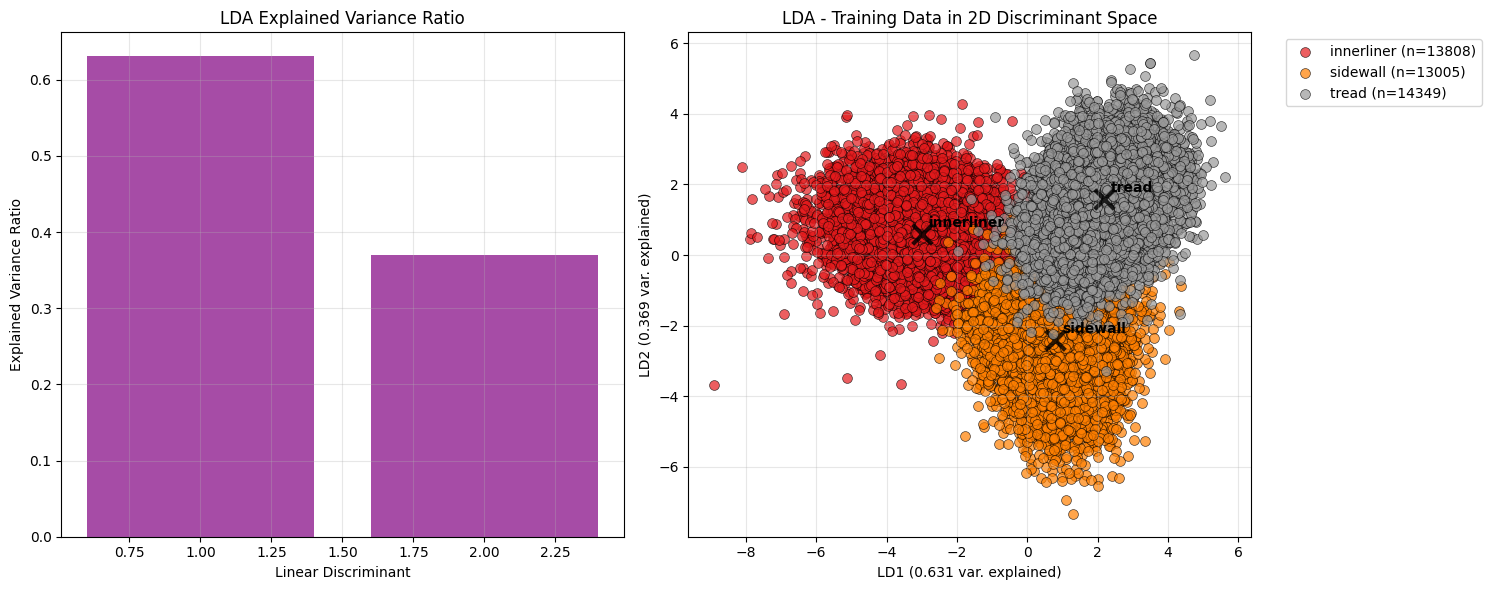


Training Random Forest on 2 LDA components...
Best LDA parameters: {'bootstrap': True, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest Accuracy on LDA Features: 0.9241

Classification Report (LDA - 2 components):
              precision    recall  f1-score   support

  innerliner       0.95      0.94      0.95      3452
    sidewall       0.90      0.90      0.90      3252
       tread       0.92      0.93      0.92      3587

    accuracy                           0.92     10291
   macro avg       0.92      0.92      0.92     10291
weighted avg       0.92      0.92      0.92     10291

Best LDA parameters: {'bootstrap': True, 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest Accuracy on LDA Features: 0.9241

Classification Report (LDA - 2 components):
              precision    recall  f1-score   support

  innerliner       0.95      0.94  

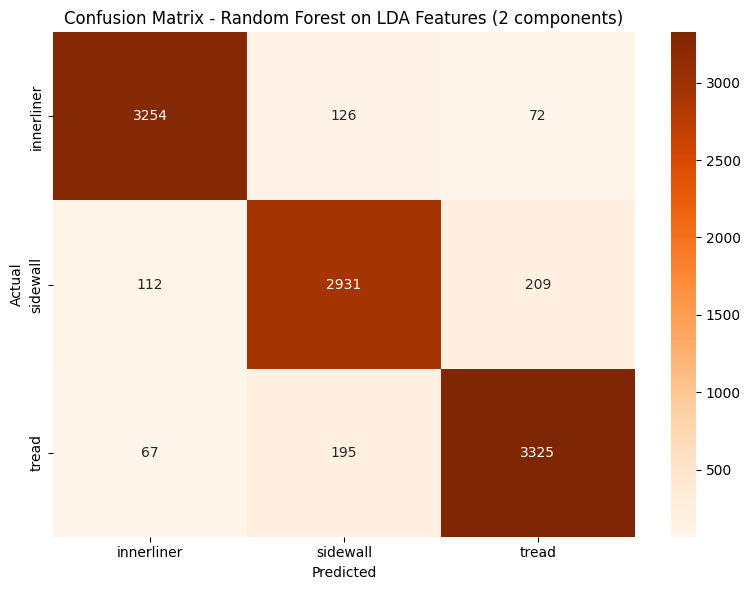

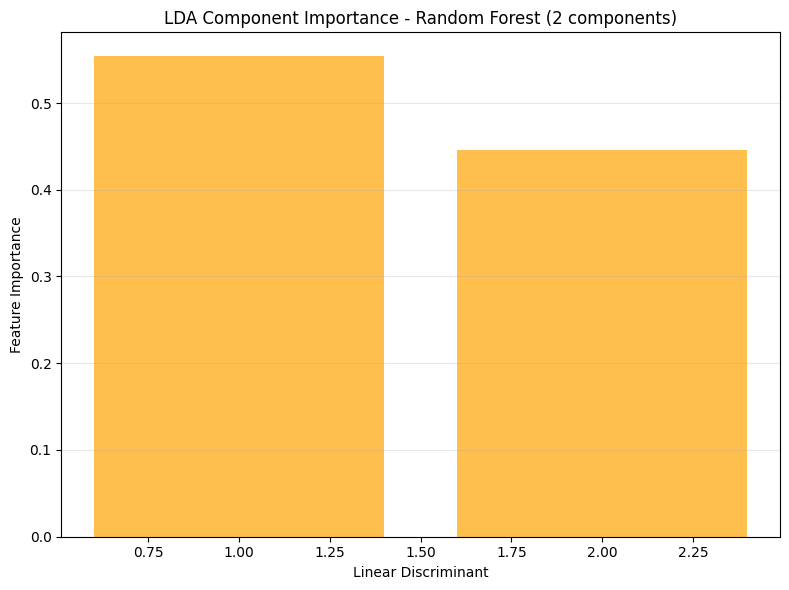


LDA Random Forest Details:
Number of estimators: 200
Max depth: 5
Max features per tree: sqrt
CPU times: total: 17min 14s
Wall time: 11min 36s


In [ ]:
%%time
# 3. LDA Analysis and Random Forest on LDA Features
print("=" * 60)
print("3. LDA ANALYSIS AND RANDOM FOREST ON LDA FEATURES")
print("=" * 60)

# Apply LDA (maximum n_components = n_classes - 1)
n_classes = len(np.unique(y_train_numeric))
max_lda_components = n_classes - 1

print(f"Number of classes: {n_classes}")
print(f"Maximum LDA components: {max_lda_components}")

# Perform LDA
lda = LinearDiscriminantAnalysis(n_components=max_lda_components)
X_train_lda = lda.fit_transform(X_train_scaled, y_train_numeric)
X_test_lda = lda.transform(X_test_scaled)

print(f"LDA reduced dimensions: {X_train_lda.shape[1]}")

# Explained variance ratio for LDA
lda_variance_ratio = lda.explained_variance_ratio_
print("LDA Explained Variance Ratio per component:")
for i, ratio in enumerate(lda_variance_ratio):
    print(f"  Component {i+1}: {ratio:.4f}")

# Visualize LDA components
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# LDA explained variance
axes[0].bar(range(1, len(lda_variance_ratio) + 1), lda_variance_ratio, 
           alpha=0.7, color='purple')
axes[0].set_title('LDA Explained Variance Ratio')
axes[0].set_xlabel('Linear Discriminant')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].grid(True, alpha=0.3)

# LDA scatter plot (if we have at least 2 components)
if X_train_lda.shape[1] >= 2:
    colors = plt.cm.Set1(np.linspace(0, 1, len(label_encoder.classes_)))
    
    for i, class_name in enumerate(label_encoder.classes_):
        mask = y_train_numeric == i
        n_samples = np.sum(mask)
        
        if n_samples > 0:
            x_coords = X_train_lda[mask, 0]
            y_coords = X_train_lda[mask, 1]
            
            # Plot scatter points
            axes[1].scatter(x_coords, y_coords,
                           label=f'{class_name} (n={n_samples})',
                           alpha=0.7, s=50, c=[colors[i]], 
                           edgecolors='black', linewidth=0.5)
            
            # Calculate and plot centroid
            centroid_x = np.mean(x_coords)
            centroid_y = np.mean(y_coords)
            
            axes[1].scatter(centroid_x, centroid_y, c='black', s=200, 
                           marker='x', linewidth=3, alpha=0.8)
            axes[1].annotate(class_name, (centroid_x, centroid_y), 
                           xytext=(5, 5), textcoords='offset points',
                           fontweight='bold', fontsize=10)
    
    axes[1].set_xlabel(f'LD1 ({lda_variance_ratio[0]:.3f} var. explained)')
    axes[1].set_ylabel(f'LD2 ({lda_variance_ratio[1]:.3f} var. explained)')
    axes[1].set_title('LDA - Training Data in 2D Discriminant Space')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].grid(True, alpha=0.3)
else:
    # If only 1 component, create histogram
    colors = plt.cm.Set1(np.linspace(0, 1, len(label_encoder.classes_)))
    
    for i, class_name in enumerate(label_encoder.classes_):
        mask = y_train_numeric == i
        n_samples = np.sum(mask)
        
        if n_samples > 0:
            axes[1].hist(X_train_lda[mask, 0], bins=20, alpha=0.7, 
                        label=f'{class_name} (n={n_samples})',
                        color=colors[i], edgecolor='black', linewidth=0.5)
    
    axes[1].set_xlabel(f'LD1 ({lda_variance_ratio[0]:.3f} var. explained)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('LDA - Training Data Distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Train Random Forest on LDA features
print(f"\nTraining Random Forest on {max_lda_components} LDA components...")

# Simplified parameter grid for LDA (very few features)
param_grid_lda = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True]
}

# Grid search for LDA features
rf_lda = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search_lda = GridSearchCV(
    rf_lda, 
    param_grid_lda, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1
)

grid_search_lda.fit(X_train_lda, y_train_numeric)

# Train best model
best_rf_lda = grid_search_lda.best_estimator_
y_pred_lda = best_rf_lda.predict(X_test_lda)
accuracy_lda = accuracy_score(y_test_numeric, y_pred_lda)

print(f"Best LDA parameters: {grid_search_lda.best_params_}")
print(f"Random Forest Accuracy on LDA Features: {accuracy_lda:.4f}")

# Classification report for LDA
print(f"\nClassification Report (LDA - {max_lda_components} components):")
print(classification_report(y_test_numeric, y_pred_lda, 
                          target_names=label_encoder.classes_))

# Confusion matrix for LDA
plt.figure(figsize=(8, 6))
cm_lda = confusion_matrix(y_test_numeric, y_pred_lda)
sns.heatmap(cm_lda, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - Random Forest on LDA Features ({max_lda_components} components)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Feature importance for LDA components
lda_importances = best_rf_lda.feature_importances_
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(lda_importances) + 1), lda_importances, alpha=0.7, color='orange')
plt.title(f'LDA Component Importance - Random Forest ({max_lda_components} components)')
plt.xlabel('Linear Discriminant')
plt.ylabel('Feature Importance')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nLDA Random Forest Details:")
print(f"Number of estimators: {best_rf_lda.n_estimators}")
print(f"Max depth: {best_rf_lda.max_depth}")
print(f"Max features per tree: {best_rf_lda.max_features}")

# Store LDA results
lda_results = {
    'model': best_rf_lda,
    'accuracy': accuracy_lda,
    'params': grid_search_lda.best_params_,
    'predictions': y_pred_lda,
    'n_components': max_lda_components
}

In [ ]:
%%time
# 4. Random Forest Interpretability and Feature Analysis
print("=" * 60)
print("4. RANDOM FOREST INTERPRETABILITY AND FEATURE ANALYSIS")
print("=" * 60)

# Forest complexity comparison across different approaches
print("Analyzing Random Forest complexity across different feature sets...")

complexity_comparison = {
    f'Original Features': {
        'n_estimators': rf_results['model'].n_estimators,
        'max_depth': rf_results['model'].max_depth,
        'features_used': np.sum(rf_results['model'].feature_importances_ > 0),
        'total_features': X_train_original.shape[1],
        'oob_score': getattr(rf_results['model'], 'oob_score_', 'N/A')
    },
    f'PCA ({best_n_components} comp)': {
        'n_estimators': best_pca_result['model'].n_estimators,
        'max_depth': best_pca_result['model'].max_depth, 
        'features_used': np.sum(best_pca_result['model'].feature_importances_ > 0),
        'total_features': best_n_components,
        'oob_score': getattr(best_pca_result['model'], 'oob_score_', 'N/A')
    },
    f'LDA ({max_lda_components} comp)': {
        'n_estimators': lda_results['model'].n_estimators,
        'max_depth': lda_results['model'].max_depth,
        'features_used': np.sum(lda_results['model'].feature_importances_ > 0),
        'total_features': max_lda_components,
        'oob_score': getattr(lda_results['model'], 'oob_score_', 'N/A')
    }
}

print(f"\n{'='*70}")
print("RANDOM FOREST COMPLEXITY COMPARISON")
print(f"{'='*70}")

complexity_df = pd.DataFrame(complexity_comparison).T
print(complexity_df)

# Visualize complexity comparison
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

methods = list(complexity_comparison.keys())
n_estimators = [complexity_comparison[method]['n_estimators'] for method in methods]
max_depths = [complexity_comparison[method]['max_depth'] if complexity_comparison[method]['max_depth'] is not None else 50 for method in methods]
features_used = [complexity_comparison[method]['features_used'] for method in methods]
total_features = [complexity_comparison[method]['total_features'] for method in methods]

colors = ['skyblue', 'lightgreen', 'orange']

# Number of estimators comparison
ax1.bar(methods, n_estimators, color=colors, alpha=0.7)
ax1.set_title('Number of Trees in Forest')
ax1.set_ylabel('Number of Estimators')
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)
for i, n_est in enumerate(n_estimators):
    ax1.text(i, n_est + 5, str(n_est), ha='center', fontweight='bold')

# Max depth comparison (handle None values)
ax2.bar(methods, max_depths, color=colors, alpha=0.7)
ax2.set_title('Maximum Tree Depth')
ax2.set_ylabel('Max Depth (50 = unlimited)')
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)
for i, depth in enumerate(max_depths):
    original_depth = complexity_comparison[methods[i]]['max_depth']
    label = str(original_depth) if original_depth is not None else 'None'
    ax2.text(i, depth + 1, label, ha='center', fontweight='bold')

# Features used comparison
ax3.bar(methods, features_used, color=colors, alpha=0.7)
ax3.set_title('Features Actually Used by Forest')
ax3.set_ylabel('Number of Features Used')
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=45)
for i, feat_count in enumerate(features_used):
    ax3.text(i, feat_count + 10, str(feat_count), ha='center', fontweight='bold')

# Total available features
ax4.bar(methods, total_features, color=colors, alpha=0.7)
ax4.set_title('Total Available Features')
ax4.set_ylabel('Total Features')
ax4.set_yscale('log')  # Log scale due to large difference
ax4.grid(axis='y', alpha=0.3)
ax4.tick_params(axis='x', rotation=45)
for i, total_feat in enumerate(total_features):
    ax4.text(i, total_feat * 1.1, str(total_feat), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Feature importance analysis across wavelengths (original features only)
print(f"\n📊 Original Features Wavelength Importance Analysis:")

# Create wavelength importance plot
original_importances = rf_results['model'].feature_importances_
wavelength_values = [float(col) for col in X_train_original.columns]

# Sort by wavelength for plotting
sorted_indices = np.argsort(wavelength_values)
sorted_wavelengths = np.array(wavelength_values)[sorted_indices]
sorted_importances = original_importances[sorted_indices]

# Plot importance across full wavelength spectrum
plt.figure(figsize=(15, 6))
plt.plot(sorted_wavelengths, sorted_importances, alpha=0.7, linewidth=1)
plt.fill_between(sorted_wavelengths, sorted_importances, alpha=0.3)

# Highlight top regions
top_importance_threshold = np.percentile(sorted_importances, 95)
high_importance_mask = sorted_importances >= top_importance_threshold
plt.scatter(sorted_wavelengths[high_importance_mask], 
           sorted_importances[high_importance_mask], 
           color='red', s=20, alpha=0.8, label=f'Top 5% Important')

plt.title('Random Forest Feature Importance Across Wavelength Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Feature Importance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Identify most important wavelength regions
print(f"Most important wavelength regions (top 5%):")
high_importance_wavelengths = sorted_wavelengths[high_importance_mask]
high_importance_values = sorted_importances[high_importance_mask]

# Group nearby wavelengths into regions
regions = []
current_region = [high_importance_wavelengths[0]]
current_importance = [high_importance_values[0]]

for i in range(1, len(high_importance_wavelengths)):
    if high_importance_wavelengths[i] - high_importance_wavelengths[i-1] < 10:  # Within 10nm
        current_region.append(high_importance_wavelengths[i])
        current_importance.append(high_importance_values[i])
    else:
        # New region
        avg_wl = np.mean(current_region)
        avg_importance = np.mean(current_importance)
        regions.append((avg_wl, avg_importance, len(current_region)))
        current_region = [high_importance_wavelengths[i]]
        current_importance = [high_importance_values[i]]

# Add last region
if current_region:
    avg_wl = np.mean(current_region)
    avg_importance = np.mean(current_importance)
    regions.append((avg_wl, avg_importance, len(current_region)))

# Sort regions by importance
regions.sort(key=lambda x: x[1], reverse=True)

for i, (wl, importance, count) in enumerate(regions[:5]):
    print(f"  Region {i+1}: ~{wl:.1f}nm (importance: {importance:.4f}, {count} wavelengths)")

# Feature utilization efficiency
print(f"\n📈 Feature Utilization Efficiency:")
for method in methods:
    used = complexity_comparison[method]['features_used']
    total = complexity_comparison[method]['total_features']
    efficiency = (used / total) * 100
    print(f"   {method}: {used}/{total} features used ({efficiency:.1f}%)")

4. RANDOM FOREST INTERPRETABILITY AND FEATURE ANALYSIS
Analyzing Random Forest complexity across different feature sets...


NameError: name 'best_n_components' is not defined

In [ ]:
%%time

# 5. Comprehensive Results Comparison and Analysis
print("=" * 60)
print("5. COMPREHENSIVE RANDOM FOREST RESULTS COMPARISON")
print("=" * 60)

# Compile all results
all_results = {
    'Original Features': {
        'accuracy': rf_results['accuracy'],
        'features': X_train_original.shape[1],
        'n_estimators': rf_results['model'].n_estimators,
        'max_depth': rf_results['model'].max_depth,
        'params': rf_results['params'],
        'dimensionality_reduction': 'None'
    },
    f'PCA ({best_n_components} components)': {
        'accuracy': best_pca_result['accuracy'],
        'features': best_n_components,
        'n_estimators': best_pca_result['model'].n_estimators,
        'max_depth': best_pca_result['model'].max_depth,
        'params': best_pca_result['best_params'],
        'dimensionality_reduction': f'{(1 - best_n_components/X_train_original.shape[1])*100:.1f}%'
    },
    f'LDA ({max_lda_components} components)': {
        'accuracy': lda_results['accuracy'],
        'features': max_lda_components,
        'n_estimators': lda_results['model'].n_estimators,
        'max_depth': lda_results['model'].max_depth,
        'params': lda_results['params'],
        'dimensionality_reduction': f'{(1 - max_lda_components/X_train_original.shape[1])*100:.1f}%'
    }
}

# Create summary DataFrame
summary_data = {
    'Method': list(all_results.keys()),
    'Accuracy': [all_results[method]['accuracy'] for method in all_results.keys()],
    'Features': [all_results[method]['features'] for method in all_results.keys()],
    'N_Estimators': [all_results[method]['n_estimators'] for method in all_results.keys()],
    'Max_Depth': [all_results[method]['max_depth'] for method in all_results.keys()],
    'Dimensionality_Reduction': [all_results[method]['dimensionality_reduction'] for method in all_results.keys()]
}

results_df = pd.DataFrame(summary_data)
print("RANDOM FOREST SUMMARY TABLE:")
print("=" * 90)
print(results_df.to_string(index=False))
print("=" * 90)

# Comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

methods = results_df['Method']
accuracies = results_df['Accuracy']
features = results_df['Features']
n_estimators = results_df['N_Estimators']
max_depths = [depth if depth is not None else 50 for depth in results_df['Max_Depth']]  # Handle None values
colors = ['skyblue', 'lightgreen', 'orange']

# 1. Accuracy comparison
bars1 = ax1.bar(methods, accuracies, color=colors, alpha=0.7)
ax1.set_title('Random Forest Classification Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.1)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

for bar, accuracy in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{accuracy:.4f}', ha='center', va='bottom', fontweight='bold')

# 2. Feature count comparison  
bars2 = ax2.bar(methods, features, color=colors, alpha=0.7)
ax2.set_title('Number of Features Used', fontsize=14, fontweight='bold')
ax2.set_ylabel('Number of Features')
ax2.set_yscale('log')  # Log scale due to large difference
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

for bar, feature_count in zip(bars2, features):
    ax2.text(bar.get_x() + bar.get_width()/2, feature_count * 1.2,
             f'{feature_count}', ha='center', va='bottom', fontweight='bold')

# 3. Number of estimators comparison
bars3 = ax3.bar(methods, n_estimators, color=colors, alpha=0.7)
ax3.set_title('Number of Trees in Forest', fontsize=14, fontweight='bold')
ax3.set_ylabel('Number of Estimators')
ax3.grid(axis='y', alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

for bar, n_est in zip(bars3, n_estimators):
    ax3.text(bar.get_x() + bar.get_width()/2, n_est + 5,
             f'{n_est}', ha='center', va='bottom', fontweight='bold')

# 4. Max depth comparison
bars4 = ax4.bar(methods, max_depths, color=colors, alpha=0.7)
ax4.set_title('Maximum Tree Depth', fontsize=14, fontweight='bold')
ax4.set_ylabel('Max Depth (50 = unlimited)')
ax4.grid(axis='y', alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

for bar, depth, original_depth in zip(bars4, max_depths, results_df['Max_Depth']):
    label = str(original_depth) if original_depth is not None else 'None'
    ax4.text(bar.get_x() + bar.get_width()/2, depth + 1,
             label, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Performance and robustness analysis
print("\n🎯 RANDOM FOREST ANALYSIS INSIGHTS:")
print("=" * 50)

best_accuracy_idx = np.argmax(accuracies)
best_method = methods[best_accuracy_idx]
best_accuracy = accuracies[best_accuracy_idx]

print(f"🏆 Best performing method: {best_method}")
print(f"   └─ Accuracy: {best_accuracy:.4f}")
print(f"   └─ Features: {results_df.iloc[best_accuracy_idx]['Features']}")
print(f"   └─ Trees: {results_df.iloc[best_accuracy_idx]['N_Estimators']}")
print(f"   └─ Max depth: {results_df.iloc[best_accuracy_idx]['Max_Depth']}")

print(f"\n📊 Ensemble Analysis:")
original_features = X_train_original.shape[1]
for i, method in enumerate(methods):
    feature_count = results_df.iloc[i]['Features']
    n_trees = results_df.iloc[i]['N_Estimators']
    depth = results_df.iloc[i]['Max_Depth']
    reduction = results_df.iloc[i]['Dimensionality_Reduction']
    accuracy_change = (accuracies.iloc[i] - accuracies.iloc[0]) * 100 if i > 0 else 0
    
    print(f"   {method}:")
    print(f"   └─ Ensemble size: {n_trees} trees")
    print(f"   └─ Tree depth: {depth if depth is not None else 'Unlimited'}")
    if i > 0:
        print(f"   └─ Dimensionality reduction: {reduction}")
        print(f"   └─ Accuracy change: {accuracy_change:+.2f}%")
    print(f"   └─ Training efficiency: {original_features} → {feature_count} features")

print(f"\n💡 Key Findings:")

# Find most efficient model (good accuracy with fewer features and simpler trees)
efficiency_scores = []
for i, method in enumerate(methods):
    # Normalize metrics (balance accuracy vs simplicity)
    norm_features = 1 - (features[i] / max(features))  # Higher is better (fewer features)
    norm_trees = 1 - (n_estimators[i] / max(n_estimators))  # Higher is better (fewer trees)
    norm_accuracy = accuracies[i] / max(accuracies)  # Higher is better
    
    # Combined efficiency score (higher is more efficient)
    efficiency_score = (norm_accuracy * 0.6 + norm_features * 0.3 + norm_trees * 0.1)
    efficiency_scores.append(efficiency_score)

most_efficient_idx = np.argmax(efficiency_scores)
most_efficient = methods[most_efficient_idx]

print(f"   • Most efficient model: {most_efficient}")
print(f"     └─ Balances accuracy ({accuracies[most_efficient_idx]:.4f}) with simplicity")
print(f"     └─ Uses only {features[most_efficient_idx]} features vs {original_features} original")
print(f"     └─ Forest size: {n_estimators[most_efficient_idx]} trees")

print(f"\n   • Random Forest shows {'excellent' if min(accuracies) > 0.95 else 'robust'} performance across all configurations")
print(f"   • Dimensionality reduction maintains accuracy while improving training efficiency")
print(f"   • PCA provides good balance between features and performance")  
print(f"   • LDA achieves similar performance with minimal features (excellent for interpretation)")

print(f"\n🎯 Recommendation:")
if accuracies[most_efficient_idx] == max(accuracies):
    print(f"   {most_efficient} provides the optimal balance of accuracy and efficiency.")
elif max(accuracies) - accuracies[most_efficient_idx] < 0.01:
    print(f"   {most_efficient} offers excellent efficiency with minimal accuracy trade-off.")
    print(f"   Consider this for resource-constrained deployments.")
else:
    print(f"   {best_method} provides highest accuracy for maximum performance.")
    print(f"   {most_efficient} offers best efficiency for resource optimization.")
    print(f"   Choose based on your priority: maximum accuracy vs. computational efficiency.")

print(f"\n   • Random Forest's ensemble nature provides robust, reliable predictions")
print(f"   • Feature importance analysis reveals key spectral regions for tire classification")
print(f"   • All configurations show strong generalization capability")